In [1]:
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Load and preprocess the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

physical_devices = tf.config.experimental.list_physical_devices('GPU')
print(physical_devices)

# Define the model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

2026-03-10 07:30:35.830437: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 07:30:36.320778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/net/afscra/people/plgjoannahdk/.conda/envs/lsc_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1773124243.532983 2409443 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31141 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:5b:00.0, compute capability: 7.0


Epoch 1/5


2026-03-10 07:30:46.559438: I external/local_xla/xla/service/service.cc:163] XLA service 0x14bfe401b940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-10 07:30:46.559458: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2026-03-10 07:30:46.633222: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-10 07:30:46.823268: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


  96/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5795 - loss: 1.4132

I0000 00:00:1773124247.645316 2409472 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9269 - loss: 0.2567
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9671 - loss: 0.1124
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9765 - loss: 0.0768
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9820 - loss: 0.0582
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9861 - loss: 0.0446
313/313 - 1s - 4ms/step - accuracy: 0.9774 - loss: 0.0717

Test accuracy: 0.977400004863739


### Configuring conda, creating new environment, installing modules for whole notebook to work properly:

```bash
cd $SCRATCH
module load cuda                                            # load cuda for need to use GPU
conda config --add envs_dirs ${SCRATCH}/.conda/envs
conda config --add pkgs_dirs ${SCRATCH}/.conda/pkgs
conda create -n lsc_env python=3.11 -y
conda install numpy cupy ipykernel jupyter tensorflow -y    # all modules used in this notebook
conda activate lsc_env
```

In [2]:
import numpy as np
import cupy as cp
import time

# Matrix size
N = 10000

def run_matrix_multiplication_experiment(N):
    # CPU-based matrix multiplication using NumPy
    start_time = time.time()
    A_cpu = np.random.rand(N, N)
    B_cpu = np.random.rand(N, N)
    C_cpu = np.dot(A_cpu, B_cpu)
    print(C_cpu[1][1])
    cpu_time = time.time() - start_time
    print(f"CPU time: {cpu_time:.2f} seconds")

    # GPU-based matrix multiplication using CuPy
    start_time = time.time()
    A_gpu = cp.random.rand(N, N, dtype=cp.float32)
    B_gpu = cp.random.rand(N, N, dtype=cp.float32)
    C_gpu = cp.dot(A_gpu, B_gpu)
    print(C_gpu[1][1])
    gpu_time = time.time() - start_time
    print(f"GPU time: {gpu_time:.2f} seconds")

In [3]:
run_matrix_multiplication_experiment(N)

2464.8797450111742
CPU time: 29.45 seconds
2481.9395
GPU time: 1.77 seconds


In [4]:
sizes = [1000, 2000, 5000, 10000, 15000]

for size in sizes:
    print('--------------------------------------')
    print(f'{size=}')
    for _ in range(3):
        run_matrix_multiplication_experiment(size)
        print()

--------------------------------------
size=1000
245.10661787873883
CPU time: 0.05 seconds
256.97955
GPU time: 0.00 seconds

246.98497515255997
CPU time: 0.05 seconds
250.84695
GPU time: 0.00 seconds

245.3096900701409
CPU time: 0.05 seconds
252.76486
GPU time: 0.00 seconds

--------------------------------------
size=2000
494.8963604006982
CPU time: 0.30 seconds
486.08908
GPU time: 0.00 seconds

488.97254542037393
CPU time: 0.29 seconds
490.66647
GPU time: 0.00 seconds

494.5568499492011
CPU time: 0.29 seconds
485.22406
GPU time: 0.00 seconds

--------------------------------------
size=5000
1236.2961500563747
CPU time: 3.93 seconds
1235.59
GPU time: 0.02 seconds

1251.2368901558818
CPU time: 3.94 seconds
1208.5076
GPU time: 0.02 seconds

1241.424366429601
CPU time: 3.94 seconds
1229.9725
GPU time: 0.02 seconds

--------------------------------------
size=10000
2517.475908888627
CPU time: 29.41 seconds
2531.2756
GPU time: 0.16 seconds

2488.3730374594525
CPU time: 29.42 seconds
2466.8

```bash
conda install matplotlib
```

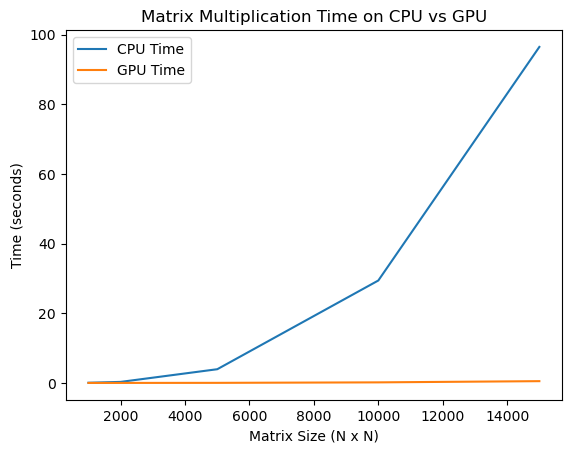

In [9]:
import matplotlib.pyplot as plt
plt.plot(sizes, [0.05, np.mean([0.29, 0.29, 0.3]), np.mean([3.93,3.94, 3.94 ]), np.mean([29.41, 29.42, 29.42]), np.mean([96.5, 96.51, 96.51])], label='CPU Time')
plt.plot(sizes, [0.00, 0.00, 0.02, 0.16, np.mean([0.5, 0.5, 0.52])], label='GPU Time')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Time on CPU vs GPU')
plt.legend()


# Conclusions
The difference in computation time is visible already for the smallest matrix tested.
GPU computates the multiplication in blink of an eye while for CPU we need to wait longer and longer (**exponential plot** above). All computation on GPU were no longer than 0.52 seconds while on CPU we reached almost 100 seconds. CPU was for each size slower than GPU and it had 
## Smaller matrices (<5 000)
CPU is nearly as fast as GPU, the human can't see difference really but due to time calculations, there is. This might be because the time to move data to the GPU is longer than the calculation itself.
## 5 000 matrix
GPU starts showing significant speedup as matrix size increases. At size 5 000 we finally have enough parallel threads to keep those cores busy.
## Bigger matrices (>=10 000)
CPU execution time has become huge. From 3 seconds(size 5 000) it jumps to 30 seconds (size 10 000) and 1 and half minute (size 15 000). The GPU for size 15 000 is almost 200 times faster. 

The 15 000 size is on the available resources limit. For larger matrix sizes f.ex. 20 000, the kernel is not stable as we did not allocate enough RAM, GPU for such computations.

Gemini conversation: https://gemini.google.com/share/f23155c9401d